# Figure 2: Tissue-specific pathway retention

This notebook regenerates a tissue-specific pathway-retention heatmap from the local **ExposoGraph** package.

Inputs used here:

- `ExposoGraph.build_reference_graph()` for the bundled reference knowledge graph.
- `ExposoGraph.get_tissue_expression()` for HPA/GTEx-derived tissue expression in nTPM.
- Class-to-carcinogen mappings defined below from the reference graph's `edge.carcinogen` labels.

The default calculation treats a class edge as retained in a tissue when every enzyme/gene endpoint on that edge has tissue expression greater than or equal to `TPM_THRESHOLD`. Non-enzyme context nodes are retained. This matches the figure title wording (`TPM expression threshold`) and avoids using the normalized tissue-weight threshold used by some ExposoGraph API helpers.

Note: the current bundled reference graph does not contain explicit Aristolochic-acid pathway edges. That row is kept as `n/a` so the absence is visible rather than silently imputed.


In [1]:
from __future__ import annotations

import csv
import sys
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Make the notebook robust whether it is launched from the repo root or from Figures_Notebook/.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "ExposoGraph").is_dir() and (candidate / "pyproject.toml").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the ExposoGraph repository root.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

OUTPUT_DIR = REPO_ROOT / "Figures_Notebook" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TPM_THRESHOLD = 0.25
TISSUES = ["Liver", "Lung", "Prostate", "Bladder", "Colon", "Breast", "Kidney", "Esophagus"]

print(f"Repository root: {REPO_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Repository root: /Users/julhashkazi/Documents/ExposoGraph_work
Output directory: /Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output


## Class definitions

The rows below aggregate ExposoGraph `edge.carcinogen` labels into manuscript-level carcinogen classes. Edit this mapping if the manuscript figure should use a narrower or broader class definition.


In [2]:
CLASS_CARCINOGENS = OrderedDict([
    ("PAHs", ["BaP", "DMBA"]),
    ("Heterocyclic amines", ["PhIP", "MeIQx"]),
    ("Arylamines", ["4ABP", "Benzidine"]),
    ("Aflatoxins", ["AFB1"]),
    ("Nitrosamines", ["NDMA", "NDEA", "NNK"]),
    ("Benzene", ["Benzene"]),
    ("Vinyl chloride", ["VinylChloride"]),
    ("Alcohol(Acetaldehyde)", ["Acetaldehyde"]),
    ("Formaldehyde", ["Formaldehyde"]),
    ("Heavy metals", ["As", "Cd", "CrVI", "Ni", "Be"]),
    (
        "Dioxins/PCBs",
        [
            "TCDD", "PCB_126", "PCB_169", "PCB_77", "PCB_118", "PCB_153", "PCB_138",
            "PeCDF_23478", "HCB", "PCP", "Lindane", "DDT", "DDE", "Chlordane",
            "Heptachlor", "Toxaphene",
        ],
    ),
    ("Chlorinated solvents", ["TCE", "PCE"]),
    ("Estrogens", ["E2", "Testosterone", "DHT"]),
    ("Aristolochic acid", ["AristolochicAcid", "Aristolochic_acid", "AAI"]),
])

CLASS_CARCINOGENS

OrderedDict([('PAHs', ['BaP', 'DMBA']),
             ('Heterocyclic amines', ['PhIP', 'MeIQx']),
             ('Arylamines', ['4ABP', 'Benzidine']),
             ('Aflatoxins', ['AFB1']),
             ('Nitrosamines', ['NDMA', 'NDEA', 'NNK']),
             ('Benzene', ['Benzene']),
             ('Vinyl chloride', ['VinylChloride']),
             ('Alcohol(Acetaldehyde)', ['Acetaldehyde']),
             ('Formaldehyde', ['Formaldehyde']),
             ('Heavy metals', ['As', 'Cd', 'CrVI', 'Ni', 'Be']),
             ('Dioxins/PCBs',
              ['TCDD',
               'PCB_126',
               'PCB_169',
               'PCB_77',
               'PCB_118',
               'PCB_153',
               'PCB_138',
               'PeCDF_23478',
               'HCB',
               'PCP',
               'Lindane',
               'DDT',
               'DDE',
               'Chlordane',
               'Heptachlor',
               'Toxaphene']),
             ('Chlorinated solvents', ['TCE', 'PCE']),

## Compute class-specific retention

For each class and tissue, the denominator is the number of reference graph edges whose `carcinogen` label belongs to that class. The numerator is the number of those edges retained after applying the nTPM threshold to enzyme/gene endpoints.


In [3]:
from ExposoGraph import build_reference_graph, get_tissue_expression

graph = build_reference_graph()
nodes = [node.model_dump(mode="json") for node in graph.nodes]
edges = [edge.model_dump(mode="json") for edge in graph.edges]

node_type_by_id = {node["id"]: node.get("type", "") for node in nodes}
expression_by_tissue = {tissue: get_tissue_expression(tissue) for tissue in TISSUES}

def is_gene_like(node_id: str) -> bool:
    return node_type_by_id.get(node_id) in {"Enzyme", "Gene"}


def edge_retained(edge: dict[str, object], tissue: str, threshold: float = TPM_THRESHOLD) -> bool:
    expression = expression_by_tissue[tissue]
    for endpoint in (str(edge.get("source", "")), str(edge.get("target", ""))):
        if is_gene_like(endpoint) and float(expression.get(endpoint, 0.0)) < threshold:
            return False
    return True


def class_edges(carcinogens: list[str]) -> list[dict[str, object]]:
    labels = set(carcinogens)
    return [edge for edge in edges if edge.get("carcinogen") in labels]

matrix = np.full((len(CLASS_CARCINOGENS), len(TISSUES)), np.nan, dtype=float)
edge_counts: dict[str, int] = {}
retained_counts: dict[tuple[str, str], int] = {}

for row_idx, (class_name, carcinogens) in enumerate(CLASS_CARCINOGENS.items()):
    selected_edges = class_edges(carcinogens)
    edge_counts[class_name] = len(selected_edges)
    if not selected_edges:
        continue
    for col_idx, tissue in enumerate(TISSUES):
        retained = sum(edge_retained(edge, tissue) for edge in selected_edges)
        retained_counts[(class_name, tissue)] = retained
        matrix[row_idx, col_idx] = 100.0 * retained / len(selected_edges)

print(f"Reference graph: {len(nodes)} nodes / {len(edges)} edges")
for class_name in CLASS_CARCINOGENS:
    print(f"{class_name:24s} {edge_counts[class_name]:3d} class edges")

Reference graph: 214 nodes / 321 edges
PAHs                      13 class edges
Heterocyclic amines        8 class edges
Arylamines                 6 class edges
Aflatoxins                 5 class edges
Nitrosamines              13 class edges
Benzene                    3 class edges
Vinyl chloride             4 class edges
Alcohol(Acetaldehyde)      7 class edges
Formaldehyde               6 class edges
Heavy metals              42 class edges
Dioxins/PCBs              30 class edges
Chlorinated solvents      11 class edges
Estrogens                 19 class edges
Aristolochic acid          0 class edges


In [4]:
# Save the computed matrix for manuscript auditability.
csv_path = OUTPUT_DIR / "figure2_tissue_pathway_retention_matrix.csv"
with csv_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.writer(handle)
    writer.writerow(["carcinogen_class", "edge_count", *TISSUES])
    for row_idx, class_name in enumerate(CLASS_CARCINOGENS):
        row = [class_name, edge_counts[class_name]]
        for value in matrix[row_idx]:
            row.append("" if np.isnan(value) else round(float(value), 1))
        writer.writerow(row)

print(csv_path)

/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure2_tissue_pathway_retention_matrix.csv


## Render heatmap

The color scale is fixed to 40-100% to match the draft Figure 2 visual range. Cells without class edges are shown in light gray and annotated as `n/a`.


/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure2_tissue_pathway_retention.png
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure2_tissue_pathway_retention.pdf
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure2_tissue_pathway_retention.svg


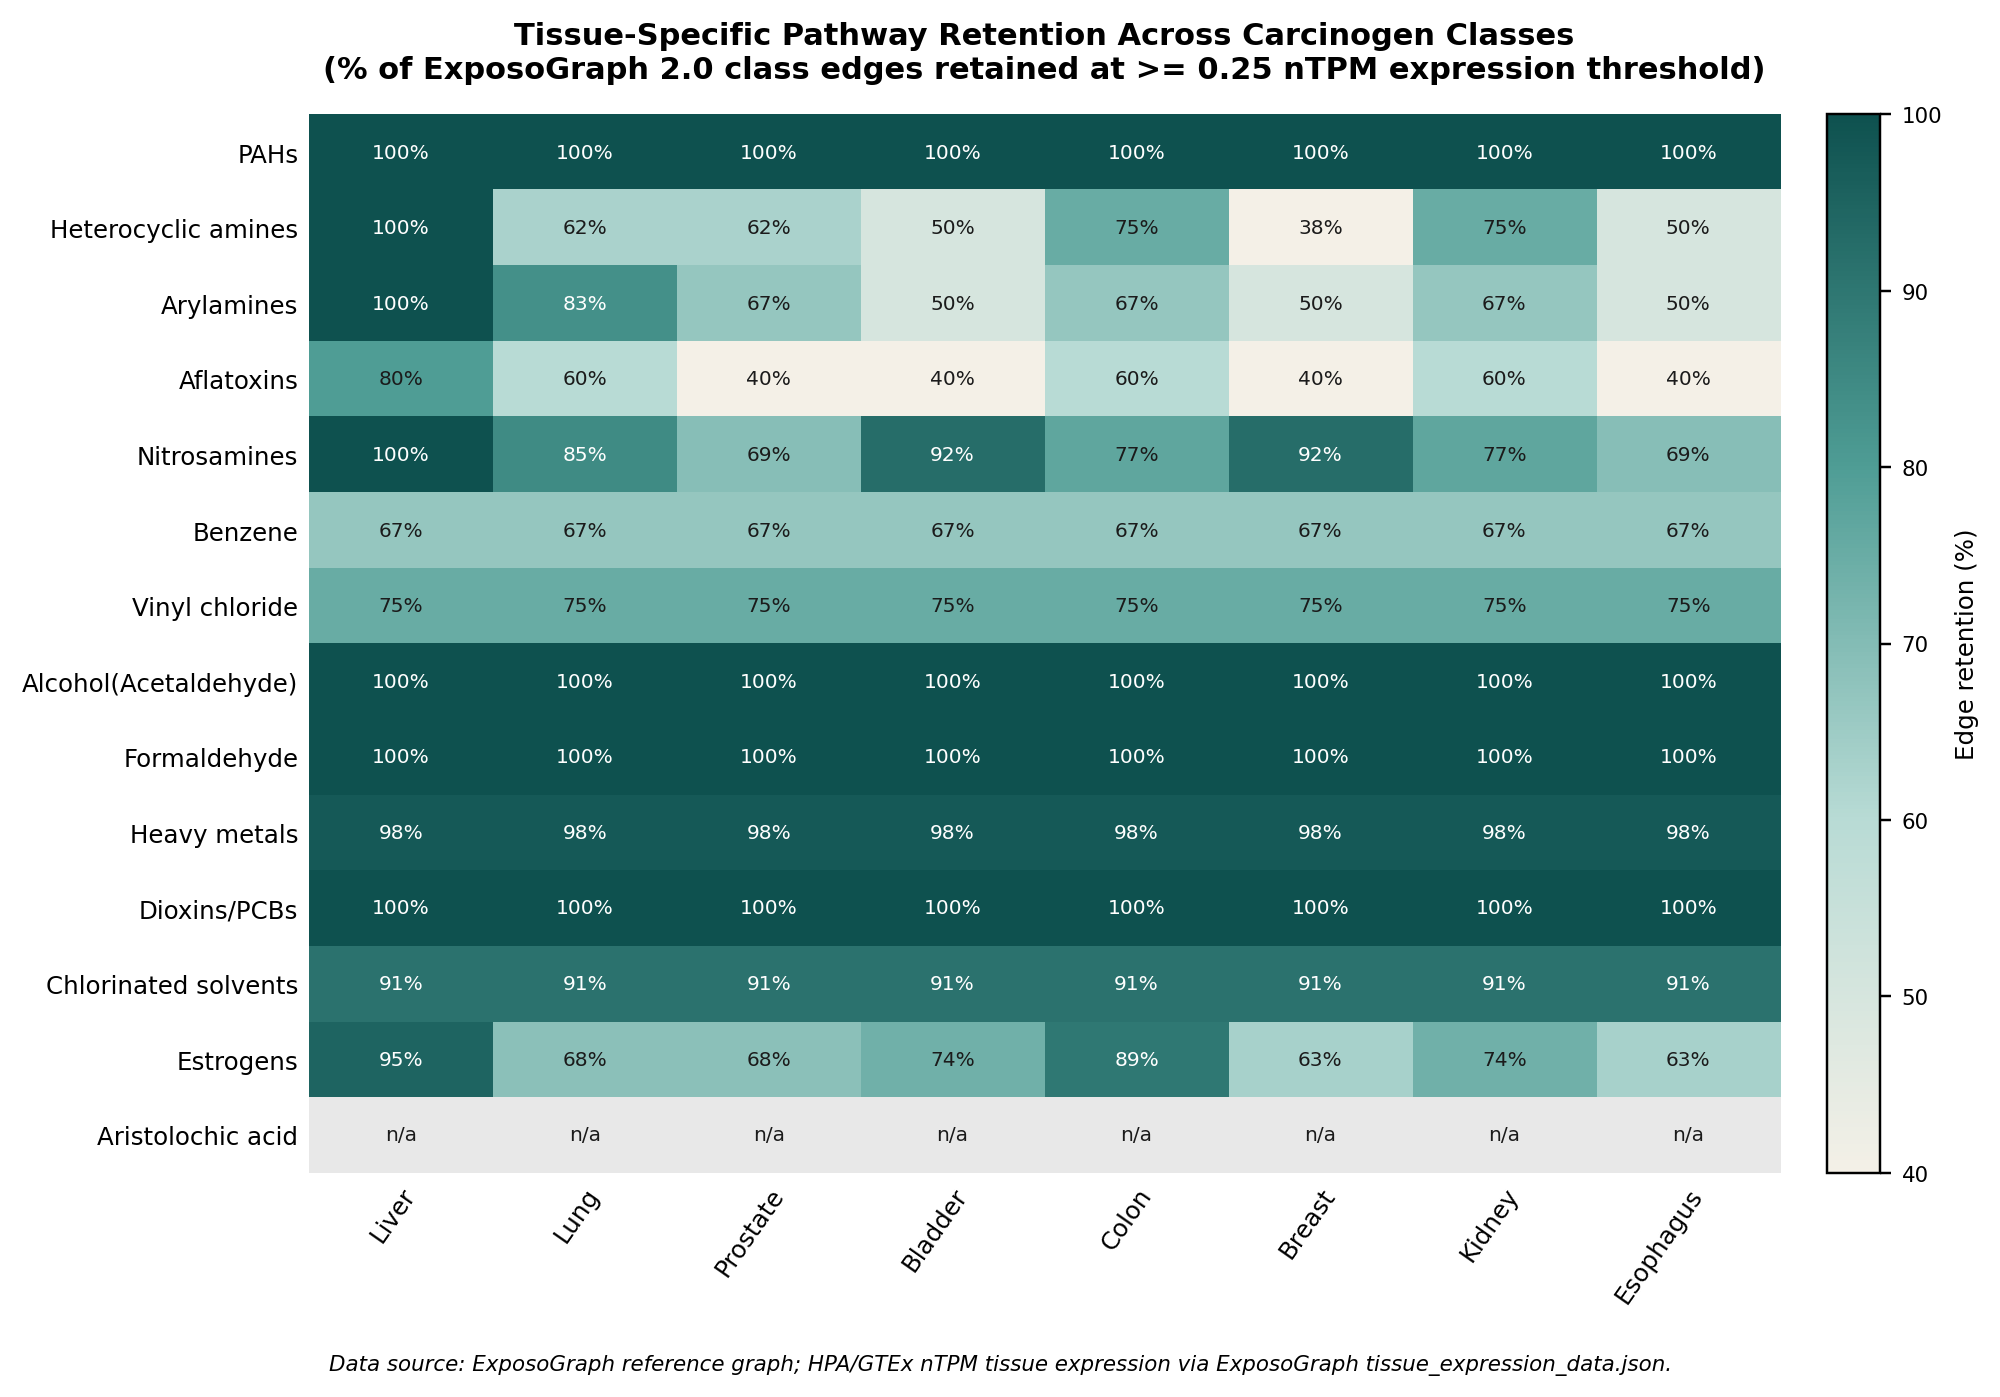

In [5]:
row_labels = list(CLASS_CARCINOGENS.keys())
plot_matrix = np.ma.masked_invalid(matrix)

cmap = LinearSegmentedColormap.from_list(
    "exposograph_teal",
    ["#f4f0e7", "#b8dbd5", "#4f9d95", "#0e514f"],
)
cmap.set_bad("#e8e8e8")

fig, ax = plt.subplots(figsize=(9.2, 6.4), dpi=220)
im = ax.imshow(plot_matrix, cmap=cmap, vmin=40, vmax=100, aspect="auto")

ax.set_xticks(np.arange(len(TISSUES)))
ax.set_xticklabels(TISSUES, rotation=55, ha="right", rotation_mode="anchor", fontsize=8)
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=8)
ax.tick_params(axis="both", length=0)

for row_idx in range(matrix.shape[0]):
    for col_idx in range(matrix.shape[1]):
        value = matrix[row_idx, col_idx]
        label = "n/a" if np.isnan(value) else f"{value:.0f}%"
        text_color = "#1b1b1b" if np.isnan(value) or value < 82 else "white"
        ax.text(col_idx, row_idx, label, ha="center", va="center", fontsize=6.6, color=text_color)

for spine in ax.spines.values():
    spine.set_visible(False)

title = (
    "Tissue-Specific Pathway Retention Across Carcinogen Classes"
    + "\n"
    + f"(% of ExposoGraph 2.0 class edges retained at >= {TPM_THRESHOLD:g} nTPM expression threshold)"
)
ax.set_title(title, fontsize=10, weight="bold", pad=12)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
cbar.set_label("Edge retention (%)", fontsize=8)
cbar.ax.tick_params(labelsize=7)

fig.text(
    0.5,
    0.015,
    "Data source: ExposoGraph reference graph; HPA/GTEx nTPM tissue expression via ExposoGraph tissue_expression_data.json.",
    ha="center",
    va="bottom",
    fontsize=7,
    style="italic",
)

fig.tight_layout(rect=(0, 0.04, 1, 1))

png_path = OUTPUT_DIR / "figure2_tissue_pathway_retention.png"
pdf_path = OUTPUT_DIR / "figure2_tissue_pathway_retention.pdf"
svg_path = OUTPUT_DIR / "figure2_tissue_pathway_retention.svg"
fig.savefig(png_path, bbox_inches="tight", dpi=300)
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")

print(png_path)
print(pdf_path)
print(svg_path)
plt.show()

## Sanity checks

These checks make figure regeneration fail loudly if the reference graph or tissue data contract changes in a way that affects the manuscript figure.


In [6]:
assert len(nodes) == 214, f"Expected 214 reference nodes, found {len(nodes)}"
assert len(edges) == 321, f"Expected 321 reference edges, found {len(edges)}"
assert TISSUES == ["Liver", "Lung", "Prostate", "Bladder", "Colon", "Breast", "Kidney", "Esophagus"]
assert edge_counts["PAHs"] > 0
assert edge_counts["Heavy metals"] > 0

missing_rows = [class_name for class_name, count in edge_counts.items() if count == 0]
print("Rows without explicit reference-graph edges:", missing_rows or "none")

Rows without explicit reference-graph edges: ['Aristolochic acid']
